In [16]:
!pip install -q openai pillow

In [17]:
from google.colab import userdata, files
from PIL import Image
import base64
from io import BytesIO
import openai

In [24]:
# -----------------------------
# API Configuration
# -----------------------------
api_key = userdata.get("api_key")

client = openai.OpenAI(
    api_key=api_key,
    base_url="https://nexusapi.navigatelabs.ai"
)

Saving IMG_20240106_130503_304.webp to IMG_20240106_130503_304 (2).webp


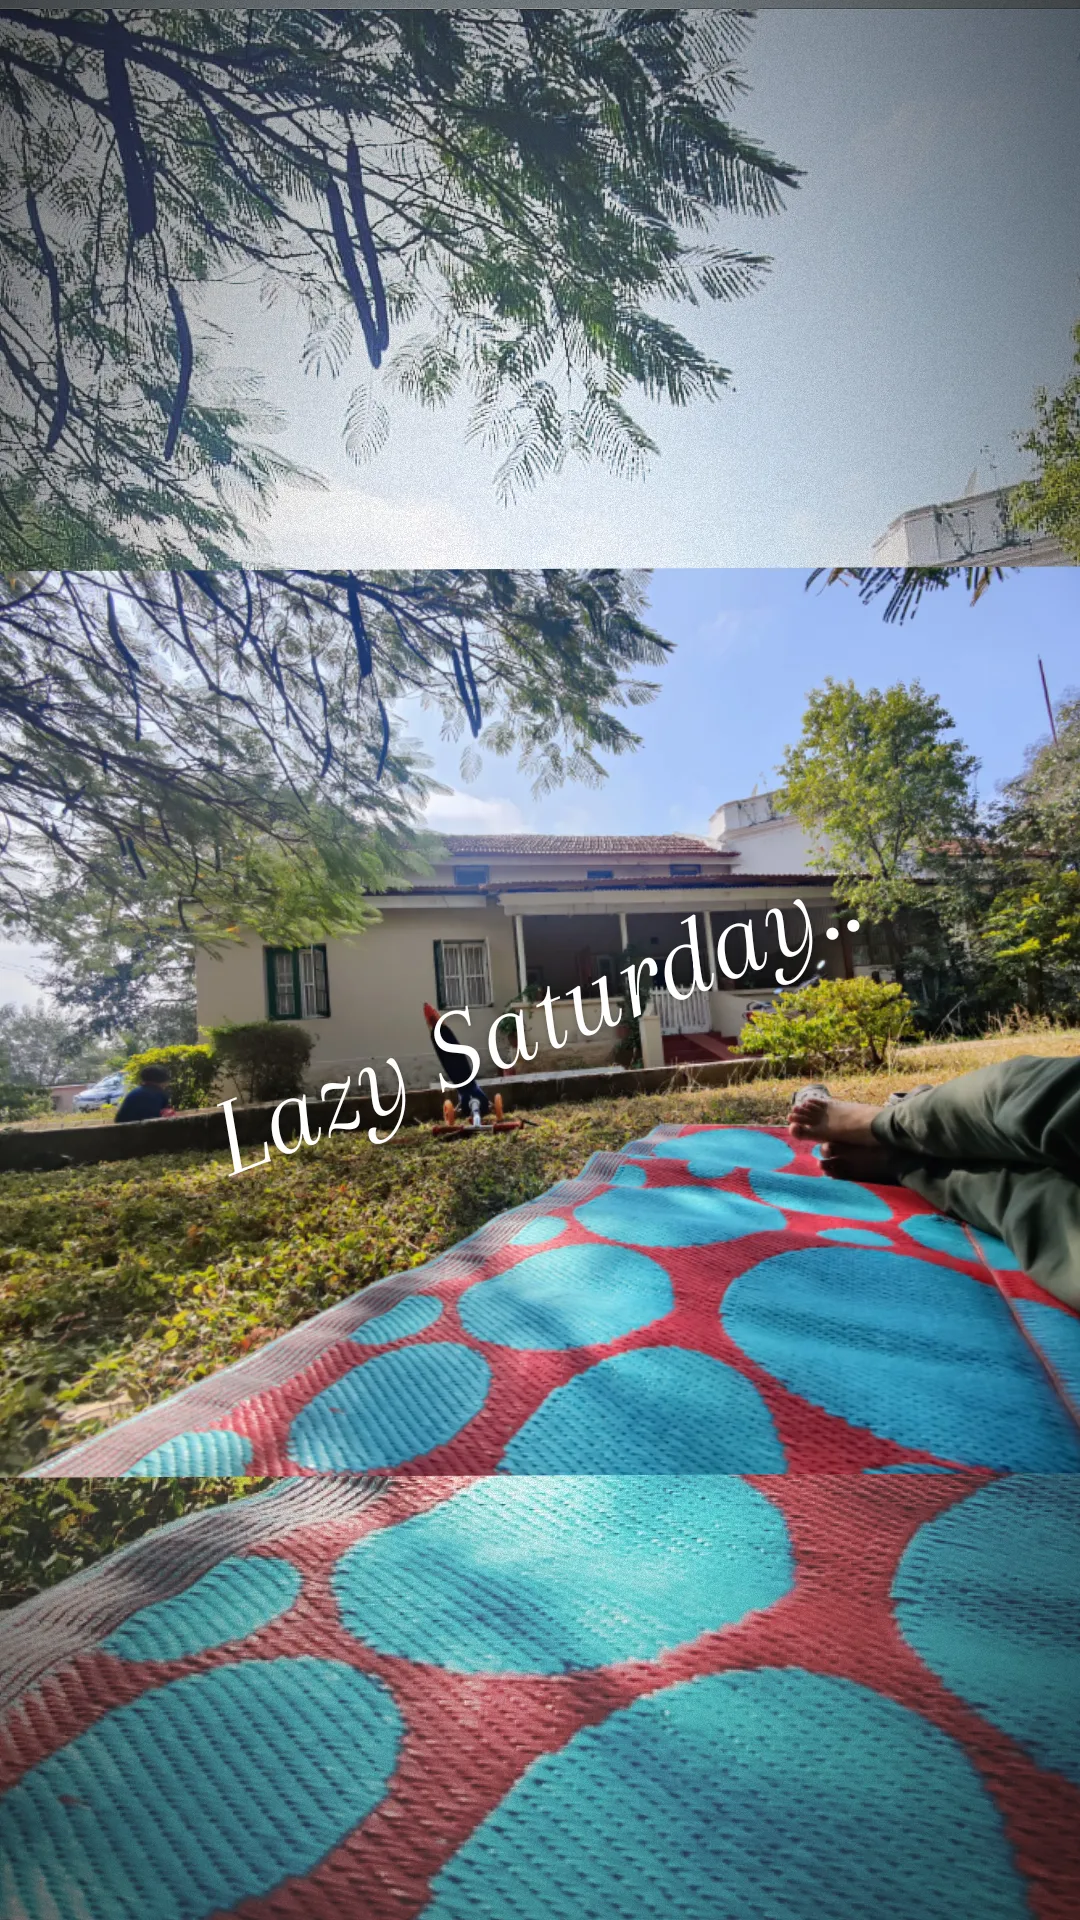

In [19]:
# -----------------------------
# Upload Image
# -----------------------------
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# Display the uploaded image
img = Image.open(image_path)
display(img)

In [20]:
# -----------------------------
# Ask user for a question
# -----------------------------
question = input("Ask a question about the uploaded image: ")

# -----------------------------
# Convert image to Base64
# -----------------------------
with open(image_path, "rb") as f:
    image_base64 = base64.b64encode(f.read()).decode("utf-8")

Ask a question about the uploaded image: explain about the image


In [26]:
# -----------------------------
# Send Image + Text to Model
# -----------------------------
response = client.chat.completions.create(
    model="gpt-4.1-nano",   # Use your vision-capable model
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": question
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{image_base64}"
                    }
                }
            ]
        }
    ]
)

print("\nModel Response:\n")
print(response.choices[0].message.content)


Model Response:

The image depicts a relaxing outdoor scene, likely in a backyard or garden, on a bright, sunny day. In the foreground, there is a colorful mat or blanket with a pattern of blue circles outlined in red. A person's legs can be seen stretched out on the mat, suggesting they are lounging and enjoying leisure time. 

In the background, there is a house with a porch, surrounded by greenery, including trees and bushes. The sky is clear, with some clouds visible, and there is a caption written across the image that says "Lazy Saturday..," indicating a calm, restful, and laid-back mood typical of a peaceful weekend day.
